# ABG Examples Data - Visualization and Analysis

This notebook loads, visualizes, and analyzes the new ABG_examples dataset containing MR brain imaging data with segmentations.

In [8]:
# Imports and configuration
import os
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

# Show plots inline when running in Jupyter
%matplotlib inline

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'ABG_examples'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)
print('Outputs:', OUTPUTS)
print('Data dir exists:', DATA_DIR.exists())

Root: /home/gobi/abigail
Data dir: /home/gobi/abigail/data/ABG_examples
Outputs: /home/gobi/abigail/outputs
Data dir exists: True


## Section 1: Load and Explore the Data

Explore the structure of ABG_examples dataset and identify available cases and modalities.

In [9]:
# List all cases in the ABG_examples directory
cases = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Total number of cases: {len(cases)}\n")

# Explore structure and available files
case_info = []
for case_dir in cases:
    case_id = case_dir.name
    files = sorted([f.name for f in case_dir.iterdir()])
    case_info.append({
        'Case ID': case_id,
        'Number of Files': len(files),
        'Files': ', '.join(files[:5]) + ('...' if len(files) > 5 else '')
    })
    print(f"Case: {case_id}")
    print(f"  Files ({len(files)}):")
    for f in files:
        print(f"    - {f}")
    print()

# Create summary dataframe
df_cases = pd.DataFrame(case_info)
print("\n" + "="*80)
print("Summary of ABG_examples cases:")
print("="*80)
print(df_cases.to_string(index=False))

Total number of cases: 5

Case: ABG-0001-AC2
  Files (12):
    - 2025-12-05-Scene.mrml
    - 2025-12-05-Scene.png
    - 4 MR ep2d_diff_3scan_trace_DVO - 3 frames Vol_5138.nrrd
    - 4 MR ep2d_diff_3scan_trace_DVO - 3 frames Vol_TSJY.seq.nrrd
    - ADC.nhdr
    - ADC.raw.gz
    - FLAIR-transformed.nrrd
    - FLAIR.nrrd
    - Segmentation.seg.nrrd
    - T1.nrrd
    - T1c.nrrd
    - T2.nrrd

Case: ABG-0015-AC4
  Files (11):
    - 2025-12-05-Scene.mrml
    - 2025-12-05-Scene.png
    - 8 MR ep2d_diff_0-500-1000_TRACEW - 3 frames V_DWSW.seq.nrrd
    - 8 MR ep2d_diff_0-500-1000_TRACEW - 3 frames V_YPS2.nrrd
    - FLAIR-transformed.nrrd
    - FLAIR.nrrd
    - Segmentation.seg.nrrd
    - T1.nrrd
    - T1c.nrrd
    - T2.nrrd
    - VolumeProperty.vp

Case: ABG-0029-MTS
  Files (21):
    - 1 localizer - imageOrientationPatient 1.nrrd
    - 1 localizer - imageOrientationPatient 2.nrrd
    - 1 localizer - imageOrientationPatient 3.nrrd
    - 10 t2_tse _TRA_448.nrrd
    - 11 t1_se_tra_320.nrrd
    - 

In [10]:
# Analyze available modalities across all cases
modality_count = defaultdict(int)
modality_by_case = defaultdict(list)

for case_dir in cases:
    case_id = case_dir.name
    files = [f.name for f in case_dir.iterdir()]
    for f in files:
        # Extract modality from filename
        if any(x in f.lower() for x in ['.nrrd', '.nhdr', '.raw', '.seq', '.mrml', '.png']):
            modality = f.split('.')[-1].upper() if '.' in f else f
            modality_count[modality] += 1
            if modality not in modality_by_case[case_id]:
                modality_by_case[case_id].append(modality)

print("File format distribution:")
for fmt, count in sorted(modality_count.items(), key=lambda x: x[1], reverse=True):
    print(f"  {fmt}: {count} files")

# Identify key medical imaging modalities
imaging_modalities = ['T1', 'T1c', 'T2', 'FLAIR', 'ADC', 'DWI']
print("\n\nMedical imaging modalities found:")
for modality in imaging_modalities:
    count = sum(1 for case_id in modality_by_case for mod in modality_by_case[case_id] if modality.upper() in mod.upper())
    cases_with_mod = sum(1 for case_id in modality_by_case for mod in modality_by_case[case_id] if modality.upper() in mod.upper())
    if count > 0:
        print(f"  {modality}: found in {cases_with_mod} cases")

File format distribution:
  NRRD: 42 files
  NHDR: 26 files
  GZ: 26 files
  MRML: 5 files
  PNG: 5 files


Medical imaging modalities found:


## Section 2: Load and Visualize Sample Cases

Load NRRD/NIfTI files and visualize MR images with segmentation overlays.

In [11]:
# Helper function to load NRRD/NIfTI files
import nrrd  # Add this import at the top if not present
def load_image(filepath):
    """Load NRRD, NIfTI, or other medical imaging formats"""
    filepath = str(filepath)
    try:
        if filepath.endswith(('.nrrd', '.nhdr')):
            # Use pynrrd for NRRD/NHDR files
            data, header = nrrd.read(filepath)
        elif filepath.endswith(('.nii', '.nii.gz')):
            data = nib.load(filepath).get_fdata()
        else:
            data = nib.load(filepath).get_fdata()
        return data
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

# Select first case for visualization
first_case = cases[0]
print(f"Loading case: {first_case.name}")

case_files = {f.name: f for f in first_case.iterdir()}
print(f"Available files: {list(case_files.keys())}\n")

# Try to load T1, T2, FLAIR, and segmentation
loaded_data = {}
modalities_to_load = ['T1.nrrd', 'T2.nrrd', 'FLAIR.nrrd', 'FLAIR-transformed.nrrd', 'Segmentation.seg.nrrd', 'T1c.nrrd', 'ADC.nhdr']

for modality in modalities_to_load:
    if modality in case_files:
        data = load_image(case_files[modality])
        if data is not None:
            loaded_data[modality] = data
            print(f"{modality}: shape {data.shape}, dtype {data.dtype}, range [{data.min():.2f}, {data.max():.2f}]")

Loading case: ABG-0001-AC2
Available files: ['ADC.nhdr', 'T1c.nrrd', 'FLAIR-transformed.nrrd', 'T1.nrrd', '4 MR ep2d_diff_3scan_trace_DVO - 3 frames Vol_5138.nrrd', 'FLAIR.nrrd', '4 MR ep2d_diff_3scan_trace_DVO - 3 frames Vol_TSJY.seq.nrrd', 'Segmentation.seg.nrrd', '2025-12-05-Scene.mrml', 'T2.nrrd', '2025-12-05-Scene.png', 'ADC.raw.gz']

T1.nrrd: shape (384, 512, 144), dtype uint16, range [0.00, 1237.00]
T2.nrrd: shape (448, 512, 30), dtype uint16, range [0.00, 1287.00]
FLAIR.nrrd: shape (448, 512, 30), dtype uint16, range [0.00, 1087.00]
FLAIR-transformed.nrrd: shape (448, 512, 30), dtype uint16, range [0.00, 1087.00]
Segmentation.seg.nrrd: shape (3, 384, 512, 144), dtype uint8, range [0.00, 1.00]
T1c.nrrd: shape (384, 512, 144), dtype uint16, range [0.00, 1558.00]
ADC.nhdr: shape (128, 128, 20), dtype int16, range [0.00, 443.00]


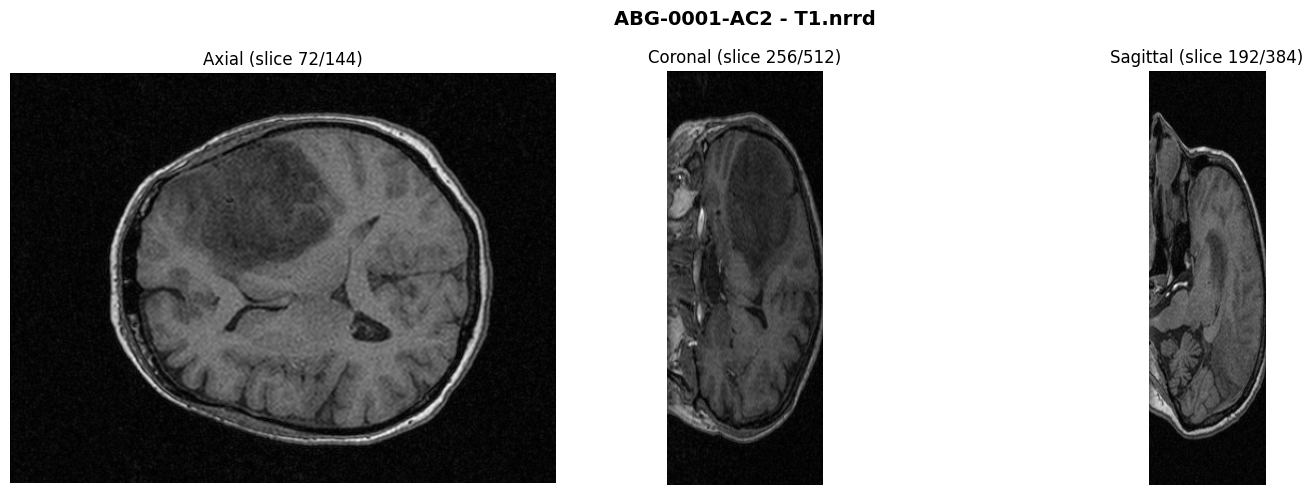

Visualization saved to /home/gobi/abigail/outputs/ABG-0001-AC2_orthogonal_slices.png


In [12]:
# Visualize orthogonal slices of the first available modality
if loaded_data:
    # Select T1 or first available modality
    modality_to_viz = 'T1.nrrd' if 'T1.nrrd' in loaded_data else list(loaded_data.keys())[0]
    img_data = loaded_data[modality_to_viz]
    
    # Normalize to 0-255 for visualization
    img_normalized = np.clip((img_data - img_data.min()) / (img_data.max() - img_data.min() + 1e-8) * 255, 0, 255)
    
    # Get middle slices
    s_z = img_data.shape[2] // 2
    s_x = img_data.shape[0] // 2
    s_y = img_data.shape[1] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{first_case.name} - {modality_to_viz}', fontsize=14, fontweight='bold')
    
    # Axial slice
    axes[0].imshow(img_normalized[:, :, s_z], cmap='gray')
    axes[0].set_title(f'Axial (slice {s_z}/{img_data.shape[2]})')
    axes[0].axis('off')
    
    # Coronal slice
    axes[1].imshow(img_normalized[:, s_y, :], cmap='gray')
    axes[1].set_title(f'Coronal (slice {s_y}/{img_data.shape[1]})')
    axes[1].axis('off')
    
    # Sagittal slice
    axes[2].imshow(img_normalized[s_x, :, :], cmap='gray')
    axes[2].set_title(f'Sagittal (slice {s_x}/{img_data.shape[0]})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS / f'{first_case.name}_orthogonal_slices.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"Visualization saved to {OUTPUTS / f'{first_case.name}_orthogonal_slices.png'}")

Segmentation shape: (3, 384, 512, 144)
Unique labels: [0 1]


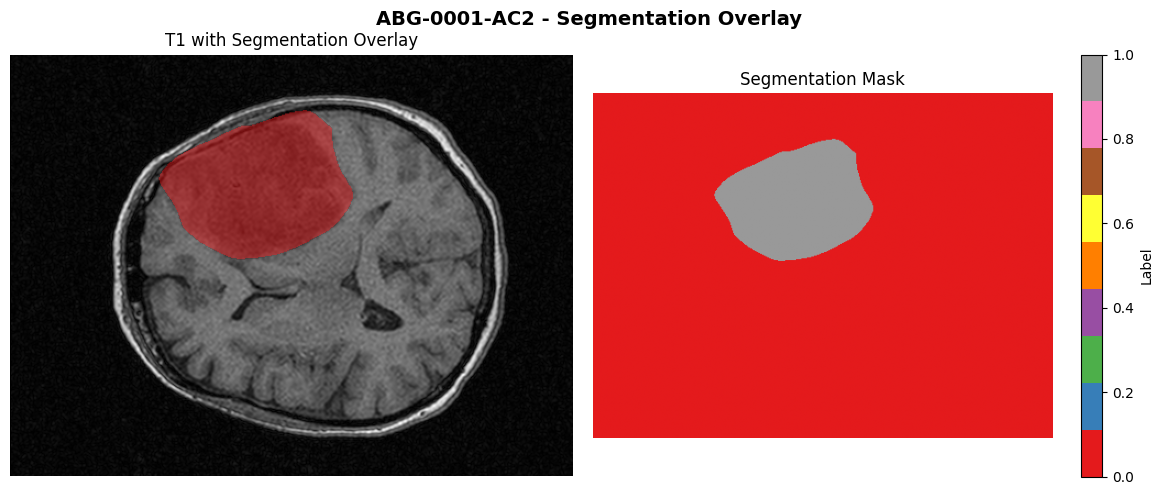

Segmentation visualization saved to /home/gobi/abigail/outputs/ABG-0001-AC2_segmentation.png


In [14]:
# Visualize segmentation if available
if 'Segmentation.seg.nrrd' in loaded_data:
    seg_data = loaded_data['Segmentation.seg.nrrd']
    
    print(f"Segmentation shape: {seg_data.shape}")
    print(f"Unique labels: {np.unique(seg_data)}")
    
    # Handle 4D segmentation arrays (e.g., (3, 384, 512, 144))
    if seg_data.ndim == 4:
        # Assume first axis is label/channel, use the first channel for visualization
        seg_vis = seg_data[0]
    else:
        seg_vis = seg_data
    
    # Visualize with overlay on T1
    if 'T1.nrrd' in loaded_data:
        t1_data = loaded_data['T1.nrrd']
        t1_normalized = np.clip((t1_data - t1_data.min()) / (t1_data.max() - t1_data.min() + 1e-8) * 255, 0, 255)
        
        # Ensure T1 and segmentation shapes match for overlay
        if t1_normalized.shape == seg_vis.shape:
            s_z = seg_vis.shape[2] // 2
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'{first_case.name} - Segmentation Overlay', fontsize=14, fontweight='bold')
            
            # T1 with segmentation overlay
            ax = axes[0]
            ax.imshow(t1_normalized[:, :, s_z], cmap='gray')
            seg_overlay = np.ma.masked_where(seg_vis[:, :, s_z] == 0, seg_vis[:, :, s_z])
            ax.imshow(seg_overlay, cmap='Set1', alpha=0.5)
            ax.set_title('T1 with Segmentation Overlay')
            ax.axis('off')
            
            # Segmentation only
            ax = axes[1]
            im = ax.imshow(seg_vis[:, :, s_z], cmap='Set1')
            ax.set_title('Segmentation Mask')
            ax.axis('off')
            plt.colorbar(im, ax=ax, label='Label')
            
            plt.tight_layout()
            plt.savefig(OUTPUTS / f'{first_case.name}_segmentation.png', dpi=100, bbox_inches='tight')
            plt.show()
            
            print(f"Segmentation visualization saved to {OUTPUTS / f'{first_case.name}_segmentation.png'}")
        else:
            print(f"Shape mismatch: T1 shape {t1_normalized.shape}, Segmentation shape {seg_vis.shape}. Cannot overlay.")

## Section 3: Intensity Statistics and Distribution Analysis

Analyze intensity distributions across different modalities and cases.

In [15]:
# Calculate statistics for each modality across all cases
statistics = []

for case_dir in cases[:3]:  # Analyze first 3 cases for efficiency
    case_id = case_dir.name
    case_files = {f.name: f for f in case_dir.iterdir()}
    
    for modality in ['T1.nrrd', 'T2.nrrd', 'FLAIR.nrrd', 'T1c.nrrd', 'ADC.nhdr']:
        if modality in case_files:
            data = load_image(case_files[modality])
            if data is not None:
                # Exclude zeros for better statistics
                data_nonzero = data[data > 0]
                
                statistics.append({
                    'Case': case_id,
                    'Modality': modality.split('.')[0],
                    'Mean': data_nonzero.mean(),
                    'Std': data_nonzero.std(),
                    'Min': data_nonzero.min(),
                    'Max': data_nonzero.max(),
                    'Median': np.median(data_nonzero),
                    'Percentile_25': np.percentile(data_nonzero, 25),
                    'Percentile_75': np.percentile(data_nonzero, 75)
                })

df_stats = pd.DataFrame(statistics)
print("Intensity Statistics (non-zero voxels):")
print(df_stats.to_string(index=False))
print("\n")

# Summary statistics by modality
print("\nSummary by Modality:")
modality_summary = df_stats.groupby('Modality')[['Mean', 'Std', 'Min', 'Max']].agg(['mean', 'std'])
print(modality_summary)

Intensity Statistics (non-zero voxels):
        Case Modality       Mean        Std Min  Max  Median  Percentile_25  Percentile_75
ABG-0001-AC2       T1  96.908067 119.329857   1 1237    30.0           17.0          180.0
ABG-0001-AC2       T2 138.003244 221.239267   1 1287    11.0            6.0          256.0
ABG-0001-AC2    FLAIR  94.874878 138.763641   1 1087    19.0           11.0          152.0
ABG-0001-AC2      T1c 122.875297 158.263039   1 1558    32.0           17.0          229.0
ABG-0001-AC2      ADC 132.999202  59.567328   1  443   115.0           91.0          161.0
ABG-0015-AC4       T1 272.563440 316.195178   1 1979   109.0           15.0          469.0
ABG-0015-AC4       T2 316.706030 344.037525   1 2199   147.0           28.0          551.0
ABG-0015-AC4    FLAIR 177.031028 211.702878   1 1352    44.0           14.0          314.0
ABG-0015-AC4      T1c 311.793934 349.471076   1 2139   176.0           15.0          519.0
ABG-0029-MTS    FLAIR 183.723451 217.054427   1 13

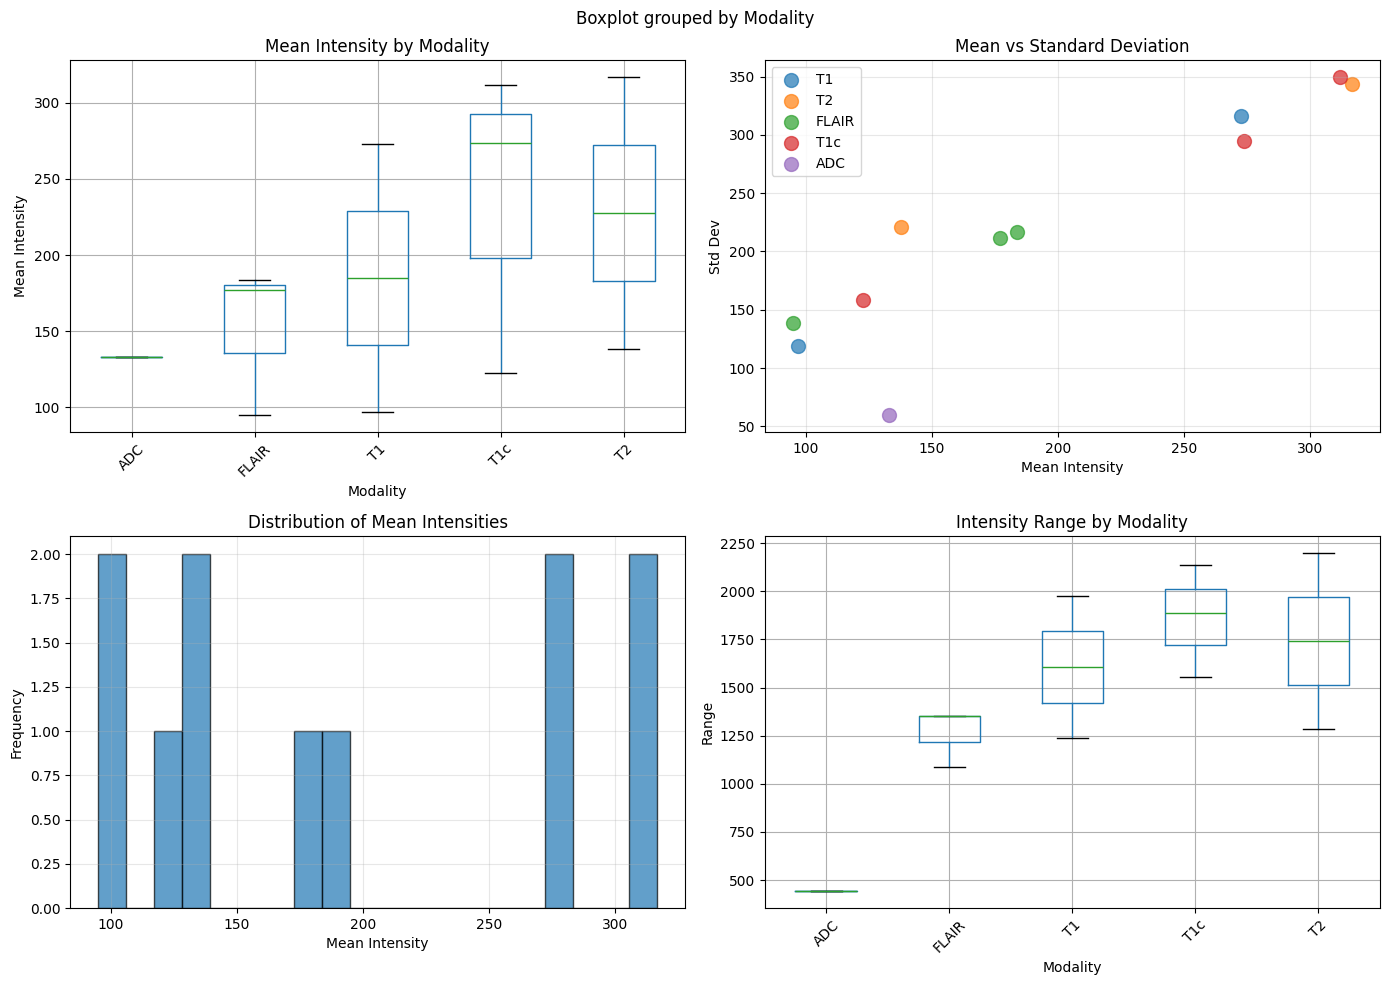

Distribution analysis saved to /home/gobi/abigail/outputs/intensity_distributions.png


In [16]:
# Visualize intensity distributions
if not df_stats.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Intensity Distribution Analysis', fontsize=14, fontweight='bold')
    
    # Box plot by modality
    ax = axes[0, 0]
    df_stats.boxplot(column='Mean', by='Modality', ax=ax)
    ax.set_title('Mean Intensity by Modality')
    ax.set_xlabel('Modality')
    ax.set_ylabel('Mean Intensity')
    plt.sca(ax)
    plt.xticks(rotation=45)
    
    # Mean vs Std scatter plot
    ax = axes[0, 1]
    for modality in df_stats['Modality'].unique():
        data = df_stats[df_stats['Modality'] == modality]
        ax.scatter(data['Mean'], data['Std'], label=modality, s=100, alpha=0.7)
    ax.set_xlabel('Mean Intensity')
    ax.set_ylabel('Std Dev')
    ax.set_title('Mean vs Standard Deviation')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Histogram of means
    ax = axes[1, 0]
    ax.hist(df_stats['Mean'], bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Mean Intensity')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Mean Intensities')
    ax.grid(True, alpha=0.3)
    
    # Range (Max - Min)
    ax = axes[1, 1]
    df_stats['Range'] = df_stats['Max'] - df_stats['Min']
    df_stats.boxplot(column='Range', by='Modality', ax=ax)
    ax.set_title('Intensity Range by Modality')
    ax.set_xlabel('Modality')
    ax.set_ylabel('Range')
    plt.sca(ax)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'intensity_distributions.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"Distribution analysis saved to {OUTPUTS / 'intensity_distributions.png'}")

## Section 4: Volume Size Analysis

Analyze the dimensions and volumes of different cases to understand dataset variability.

In [18]:
# Analyze volume dimensions across all cases
volume_info = []

for case_dir in cases:
    case_id = case_dir.name
    case_files = {f.name: f for f in case_dir.iterdir()}
    
    # Try to load any imaging file to get dimensions
    for modality_file in ['T1.nrrd', 'T2.nrrd', 'FLAIR.nrrd', 'T1c.nrrd', 'ADC.nhdr']:
        if modality_file in case_files:
            try:
                img = nib.load(str(case_files[modality_file]))
                shape = img.shape
                volume_info.append({
                    'Case': case_id,
                    'Dimensions': f"{shape[0]}x{shape[1]}x{shape[2]}",
                    'X': shape[0],
                    'Y': shape[1],
                    'Z': shape[2],
                    'Total_Voxels': shape[0] * shape[1] * shape[2]
                })
                break
            except Exception as e:
                continue

df_volumes = pd.DataFrame(volume_info)

if not df_volumes.empty:
    print("Volume Dimensions Summary:")
    print(df_volumes.to_string(index=False))
    print("\n")
    
    print("Dimension Statistics:")
    print(df_volumes[['X', 'Y', 'Z', 'Total_Voxels']].describe())
    
    # Visualize dimensions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Volume Dimensions Distribution', fontsize=14, fontweight='bold')
    
    axes[0].hist(df_volumes['X'], bins=10, edgecolor='black', alpha=0.7, color='red')
    axes[0].set_xlabel('X Dimension')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('X Dimensions')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(df_volumes['Y'], bins=10, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_xlabel('Y Dimension')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Y Dimensions')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].hist(df_volumes['Z'], bins=10, edgecolor='black', alpha=0.7, color='blue')
    axes[2].set_xlabel('Z Dimension')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Z Dimensions')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'volume_dimensions.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"\nVolume dimension analysis saved to {OUTPUTS / 'volume_dimensions.png'}")

## Section 5: Segmentation Analysis

Analyze tumor/lesion segmentation labels and their spatial distribution.

Segmentation Analysis:
        Case  Num_Labels  Tumor_Percentage
ABG-0001-AC2           2          1.629673
ABG-0015-AC4           3          2.393630
ABG-0029-MTS           4          0.491780
ABG-0064-MTS           3          0.887503
    AC2-0003           3          0.596970


Segmentation Statistics:
       Num_Labels  Tumor_Percentage
count    5.000000          5.000000
mean     3.000000          1.199911
std      0.707107          0.801911
min      2.000000          0.491780
25%      3.000000          0.596970
50%      3.000000          0.887503
75%      3.000000          1.629673
max      4.000000          2.393630


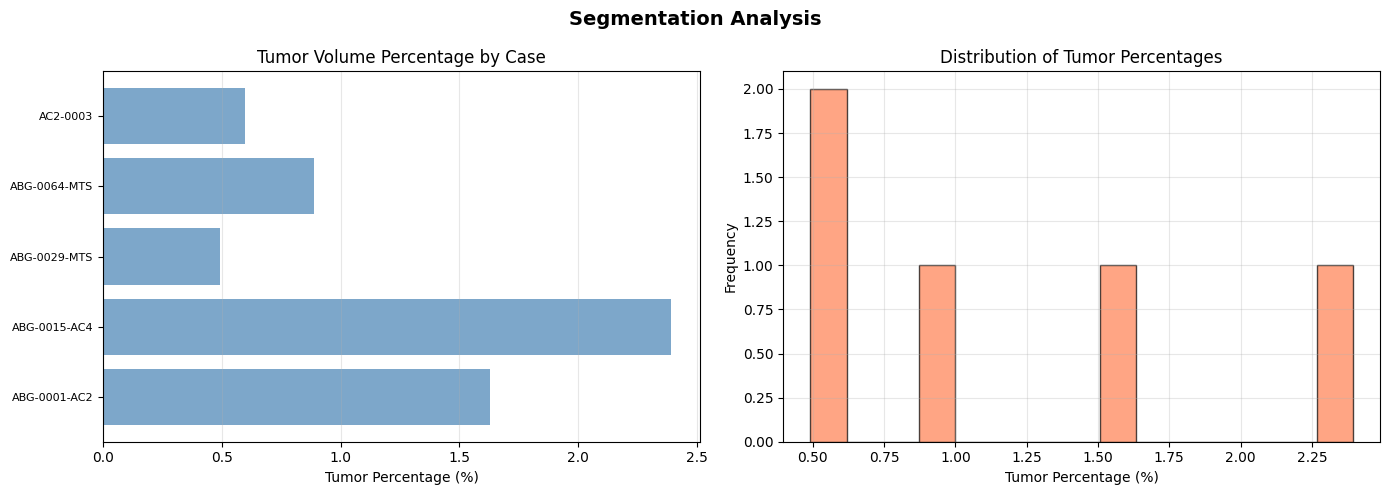


Segmentation analysis saved to /home/gobi/abigail/outputs/segmentation_analysis.png


In [19]:
# Analyze segmentation labels across cases
seg_analysis = []

for case_dir in cases:
    case_id = case_dir.name
    case_files = {f.name: f for f in case_dir.iterdir()}
    
    if 'Segmentation.seg.nrrd' in case_files:
        try:
            seg_data = load_image(case_files['Segmentation.seg.nrrd'])
            if seg_data is not None:
                unique_labels = np.unique(seg_data)
                seg_volume = np.sum(seg_data > 0)  # Non-background voxels
                total_volume = seg_data.size
                
                seg_analysis.append({
                    'Case': case_id,
                    'Num_Labels': len(unique_labels),
                    'Labels': str(unique_labels.tolist()),
                    'Tumor_Voxels': seg_volume,
                    'Total_Voxels': total_volume,
                    'Tumor_Percentage': (seg_volume / total_volume * 100)
                })
        except Exception as e:
            print(f"Error processing {case_id}: {e}")

if seg_analysis:
    df_seg = pd.DataFrame(seg_analysis)
    print("Segmentation Analysis:")
    print(df_seg[['Case', 'Num_Labels', 'Tumor_Percentage']].to_string(index=False))
    print("\n")
    
    print("Segmentation Statistics:")
    print(df_seg[['Num_Labels', 'Tumor_Percentage']].describe())
    
    # Visualize tumor percentage
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Segmentation Analysis', fontsize=14, fontweight='bold')
    
    # Bar plot of tumor percentage
    ax = axes[0]
    ax.barh(range(len(df_seg)), df_seg['Tumor_Percentage'], color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(df_seg)))
    ax.set_yticklabels(df_seg['Case'], fontsize=8)
    ax.set_xlabel('Tumor Percentage (%)')
    ax.set_title('Tumor Volume Percentage by Case')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Distribution of tumor percentage
    ax = axes[1]
    ax.hist(df_seg['Tumor_Percentage'], bins=15, edgecolor='black', alpha=0.7, color='coral')
    ax.set_xlabel('Tumor Percentage (%)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Tumor Percentages')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'segmentation_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"\nSegmentation analysis saved to {OUTPUTS / 'segmentation_analysis.png'}")
else:
    print("No segmentation files found in the dataset.")

## Section 6: Summary of Findings

Key insights and characteristics of the ABG_examples dataset.

In [20]:
print("="*80)
print("ABG EXAMPLES DATASET - ANALYSIS SUMMARY")
print("="*80)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total Cases: {len(cases)}")
print(f"   - Cases: {', '.join([c.name for c in cases])}")

print(f"\n2. IMAGING MODALITIES:")
print(f"   - Common formats: NRRD, NIfTI, NHDR")
print(f"   - Main modalities: T1, T1c, T2, FLAIR, ADC, DWI")
print(f"   - Segmentation masks: Available in .seg.nrrd format")

if not df_volumes.empty:
    print(f"\n3. VOLUME DIMENSIONS:")
    print(f"   - X dimension range: {df_volumes['X'].min()}-{df_volumes['X'].max()} voxels")
    print(f"   - Y dimension range: {df_volumes['Y'].min()}-{df_volumes['Y'].max()} voxels")
    print(f"   - Z dimension range: {df_volumes['Z'].min()}-{df_volumes['Z'].max()} voxels")

if not df_stats.empty:
    print(f"\n4. INTENSITY CHARACTERISTICS:")
    print(f"   - Intensity ranges vary by modality")
    print(f"   - Mean intensity: {df_stats['Mean'].min():.2f} - {df_stats['Mean'].max():.2f}")
    print(f"   - Standard deviation: {df_stats['Std'].min():.2f} - {df_stats['Std'].max():.2f}")

if seg_analysis:
    print(f"\n5. SEGMENTATION CHARACTERISTICS:")
    print(f"   - Number of cases with segmentation: {len(df_seg)}")
    print(f"   - Average tumor percentage: {df_seg['Tumor_Percentage'].mean():.2f}%")
    print(f"   - Tumor percentage range: {df_seg['Tumor_Percentage'].min():.2f}% - {df_seg['Tumor_Percentage'].max():.2f}%")

print(f"\n6. OUTPUT FILES:")
print(f"   - All visualizations saved to: {OUTPUTS}")
print(f"   - Files generated:")
for f in sorted(OUTPUTS.glob('*.png')):
    print(f"     * {f.name}")

print("\n" + "="*80)
print("Analysis complete. Review generated visualizations for more details.")
print("="*80)

ABG EXAMPLES DATASET - ANALYSIS SUMMARY

1. DATASET OVERVIEW:
   - Total Cases: 5
   - Cases: ABG-0001-AC2, ABG-0015-AC4, ABG-0029-MTS, ABG-0064-MTS, AC2-0003

2. IMAGING MODALITIES:
   - Common formats: NRRD, NIfTI, NHDR
   - Main modalities: T1, T1c, T2, FLAIR, ADC, DWI
   - Segmentation masks: Available in .seg.nrrd format

4. INTENSITY CHARACTERISTICS:
   - Intensity ranges vary by modality
   - Mean intensity: 94.87 - 316.71
   - Standard deviation: 59.57 - 349.47

5. SEGMENTATION CHARACTERISTICS:
   - Number of cases with segmentation: 5
   - Average tumor percentage: 1.20%
   - Tumor percentage range: 0.49% - 2.39%

6. OUTPUT FILES:
   - All visualizations saved to: /home/gobi/abigail/outputs
   - Files generated:
     * ABG-0001-AC2_orthogonal_slices.png
     * ABG-0001-AC2_segmentation.png
     * intensity_distributions.png
     * segmentation_analysis.png

Analysis complete. Review generated visualizations for more details.
